# SpillGuard: ConvNeXt-Tiny Model Development and Evaluation

This notebook implements the model development and evaluation stage for the SpillGuard project.The preprocessed dataset is already prepared using the core SAR preprocessing pipeline, including Lee filtering, log transformation, percentile clipping, CLAHE, resizing, and saving into train/validation/test folders.

## 1. Imports and Configuration

This section imports the required libraries and defines the main dataset path, output folder, and training hyperparameters. The dataset path should point to the `processed_dataset` folder created by the preprocessing notebook.

In [1]:
import os
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

### Dataset Paths

DATA_DIR = Path("processed_dataset")
OUTPUT_DIR = Path("model_outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 20
PATIENCE = 4
WARMUP_EPOCHS = 3
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
THRESHOLD = 0.5
NUM_WORKERS = 8

print("Processed dataset path:", DATA_DIR)
print("Output folder:", OUTPUT_DIR)

Processed dataset path: processed_dataset
Output folder: model_outputs


## 2. Reproducibility and Device Setup

A fixed random seed is used to make the experiment more reproducible. The device is automatically selected. If CUDA GPU is available, it will be used; otherwise, the code will run on CPU.

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 3. Dataset Verification

The processed dataset should already be divided into three folders: `train`, `val`, and `test`. Each split should contain `Class_0` and `Class_1` folders.

In this project:
- `Class_0` = No-Oil
- `Class_1` = Oil

This step verifies that the processed dataset is ready before training the model.

In [3]:

train_dir = DATA_DIR / "train"
val_dir = DATA_DIR / "val"
test_dir = DATA_DIR / "test"

print("Train folder exists:", train_dir.exists())
print("Validation folder exists:", val_dir.exists())
print("Test folder exists:", test_dir.exists())

for split_name, split_dir in [("train", train_dir), ("val", val_dir), ("test", test_dir)]:
    print(f"\n{split_name.upper()} split:")
    for class_name in ["Class_0", "Class_1"]:
        class_folder = split_dir / class_name
        num_images = len(list(class_folder.glob("*.png")))
        print(f"{class_name}: {num_images} images")

Train folder exists: True
Validation folder exists: True
Test folder exists: True

TRAIN split:
Class_0: 2607 images
Class_1: 1334 images

VAL split:
Class_0: 559 images
Class_1: 285 images

TEST split:
Class_0: 559 images
Class_1: 286 images


## 4. Image Transformations

The images were already processed and resized during the preprocessing stage. In this model stage, the images are converted to tensors and normalized using ImageNet mean and standard deviation values because ConvNeXt-Tiny is initialized with ImageNet-1K pretrained weights.

Data augmentation is applied only to the training data. Validation and test images are not augmented.


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## 5. Load Dataset

`ImageFolder` is used to load the processed image folders. It automatically assigns numeric labels based on folder names.

Since the folders are ordered alphabetically:
- `Class_0` receives label 0
- `Class_1` receives label 1

In [5]:
train_dataset = ImageFolder(root=train_dir, transform=train_transform)
val_dataset = ImageFolder(root=val_dir, transform=val_test_transform)
test_dataset = ImageFolder(root=test_dir, transform=val_test_transform)

print("Class mapping:", train_dataset.class_to_idx)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Class mapping: {'Class_0': 0, 'Class_1': 1}
Training images: 3941
Validation images: 844
Test images: 845


## 6. Class Imbalance Handling

The dataset is imbalanced because `Class_0` contains more images than `Class_1`. To reduce the effect of imbalance, two strategies are used:

1. `WeightedRandomSampler` during training.
2. `pos_weight` in `BCEWithLogitsLoss` to give more weight to the Oil class.

This is important because missing an oil spill is more critical than raising a false alarm.

In [6]:
train_labels = np.array([label for _, label in train_dataset.samples])
class_counts = np.bincount(train_labels)

print("Class counts [Class_0, Class_1]:", class_counts)

# Weighted sampler
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Positive class weight for BCEWithLogitsLoss
negative_count = class_counts[0]
positive_count = class_counts[1]
pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32).to(device)

print("Positive class weight:", pos_weight.item())

Class counts [Class_0, Class_1]: [2607 1334]
Positive class weight: 1.9542728662490845


## 7. Create DataLoaders


DataLoaders prepare image batches for model training, validation, and testing. The training DataLoader uses weighted sampling to help balance the classes during training.

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 247
Validation batches: 53
Test batches: 53


## 8. Build ConvNeXt-Tiny Model

ConvNeXt-Tiny is loaded with pretrained ImageNet weights. The original classifier head is replaced with one output neuron because this is a binary classification task:

- 0 = No-Oil
- 1 = Oil

In [8]:
def build_convnext_tiny_model():
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = convnext_tiny(weights=weights)

    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, 1)

    return model

model = build_convnext_tiny_model().to(device)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to ~/.cache\torch\hub\checkpoints\convnext_tiny-983f1562.pth


100.0%


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1, bias=True)
)


## 9. Training Setup

The model is trained using a two-phase transfer learning strategy. First, the ConvNeXt backbone is frozen so only the classifier head is trained during the warm-up stage. Then, the full model is unfrozen for fine-tuning. The positive class weight is included in the loss function to reduce the effect of class imbalance.

`BCEWithLogitsLoss` is used because the model outputs a single raw logit for binary classification.

AdamW is used as the optimizer, and a cosine learning rate scheduler is applied during training.

In [9]:
def freeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.classifier.parameters():
        param.requires_grad = True


def unfreeze_model(model):
    for param in model.parameters():
        param.requires_grad = True


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

freeze_backbone(model)
print("Trainable parameters after freezing:", count_trainable_parameters(model))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

Trainable parameters after freezing: 2305


## 10. Training and Validation

This section contains the metric calculation, training function, evaluation function, and full training loop. The best model is selected based on validation recall first, then F1-score. Recall is prioritized because false negatives are environmentally critical in oil spill detection.

In [10]:
def compute_metrics(y_true, y_pred, y_prob):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)
    y_prob = np.array(y_prob)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["roc_auc"] = np.nan

    return metrics


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
        labels_np = labels.detach().cpu().numpy().ravel()

        all_probs.extend(probs)
        all_labels.extend(labels_np)

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = (np.array(all_probs) >= THRESHOLD).astype(int)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = epoch_loss

    return metrics


@torch.no_grad()
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        labels_np = labels.cpu().numpy().ravel()

        all_probs.extend(probs)
        all_labels.extend(labels_np)

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = (np.array(all_probs) >= THRESHOLD).astype(int)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = epoch_loss

    return metrics, np.array(all_labels), np.array(all_probs), all_preds

best_val_recall = -1
best_val_f1 = -1
best_model_state = None
history = []
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    if epoch == WARMUP_EPOCHS:
        print("Unfreezing ConvNeXt-Tiny backbone for fine-tuning ...")
        unfreeze_model(model)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=LEARNING_RATE / 5,
            weight_decay=WEIGHT_DECAY
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS - WARMUP_EPOCHS
        )

        print("Trainable parameters after unfreezing:", count_trainable_parameters(model))

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics, val_labels, val_probs, val_preds = evaluate_model(model, val_loader, criterion, device)

    scheduler.step()

    print(
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Recall: {train_metrics['recall']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f}"
    )

    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Accuracy: {val_metrics['accuracy']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['roc_auc']:.4f}"
    )

    history.append({
        "epoch": epoch + 1,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()}
    })

    if (val_metrics["recall"] > best_val_recall) or (
        val_metrics["recall"] == best_val_recall and val_metrics["f1"] > best_val_f1
    ):
        best_val_recall = val_metrics["recall"]
        best_val_f1 = val_metrics["f1"]
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(best_model_state, OUTPUT_DIR / "best_convnext_tiny_spillguard.pth")
        epochs_without_improvement = 0
        print("Saved best model checkpoint.")
    
    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered after {PATIENCE} epochs without improvement.")
            break

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history_convnext.csv", index=False)
print("\nTraining complete.")


Epoch 1/20
Train Loss: 0.7702 | Train Recall: 0.9738 | Train F1: 0.7045
Val Loss: 0.6614 | Val Accuracy: 0.6836 | Val Precision: 0.5172 | Val Recall: 0.9509 | Val F1: 0.6700 | Val AUC: 0.9262
Saved best model checkpoint.

Epoch 2/20
Train Loss: 0.6296 | Train Recall: 0.9405 | Train F1: 0.7937
Val Loss: 0.5470 | Val Accuracy: 0.7855 | Val Precision: 0.6198 | Val Recall: 0.9439 | Val F1: 0.7483 | Val AUC: 0.9432

Epoch 3/20
Train Loss: 0.5271 | Train Recall: 0.9484 | Train F1: 0.8446
Val Loss: 0.4826 | Val Accuracy: 0.8187 | Val Precision: 0.6626 | Val Recall: 0.9439 | Val F1: 0.7786 | Val AUC: 0.9524

Epoch 4/20
Unfreezing ConvNeXt-Tiny backbone for fine-tuning ...
Trainable parameters after unfreezing: 27820897
Train Loss: 0.2868 | Train Recall: 0.9527 | Train F1: 0.9174
Val Loss: 0.1551 | Val Accuracy: 0.9597 | Val Precision: 0.9197 | Val Recall: 0.9649 | Val F1: 0.9418 | Val AUC: 0.9924
Saved best model checkpoint.

Epoch 5/20
Train Loss: 0.1587 | Train Recall: 0.9671 | Train F1: 0.

## 11. Final Test Evaluation

The best model checkpoint obtained during validation is loaded before testing. The final model is then evaluated using Accuracy, Precision, Recall, F1-score, and AUC-ROC.

In [11]:
model.load_state_dict(torch.load(OUTPUT_DIR / "best_convnext_tiny_spillguard.pth", map_location=device))
model.to(device)

criterion_test = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

test_metrics, test_labels, test_probs, test_preds = evaluate_model(model, test_loader, criterion_test, device)

print("Final Test Metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=["No-Oil", "Oil"], zero_division=0))

metrics_table = pd.DataFrame([{
    "Model": "ConvNeXt-Tiny",
    "Accuracy": test_metrics["accuracy"],
    "Precision": test_metrics["precision"],
    "Recall": test_metrics["recall"],
    "F1-score": test_metrics["f1"],
    "AUC-ROC": test_metrics["roc_auc"],
    "Threshold": THRESHOLD
}])

metrics_table.to_csv(OUTPUT_DIR / "final_metrics_table_convnext.csv", index=False)
metrics_table

Final Test Metrics:
accuracy: 0.9101
precision: 0.7966
recall: 0.9860
f1: 0.8812
roc_auc: 0.9925
loss: 0.2623

Classification Report:
              precision    recall  f1-score   support

      No-Oil       0.99      0.87      0.93       559
         Oil       0.80      0.99      0.88       286

    accuracy                           0.91       845
   macro avg       0.89      0.93      0.90       845
weighted avg       0.93      0.91      0.91       845



,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC,Threshold
0,ConvNeXt-Tiny,0.910059,0.79661,0.986014,0.88125,0.992519,0.5


## 12. Performance Visualization 


This section creates the main performance figures needed:

 - Training and validation loss curve
 - Training and validation recall curve
 - Training and validation F1-score curve
 - Confusion matrix
 - ROC curve

 The confusion matrix is especially important because it shows false negatives, which represent missed oil spills.

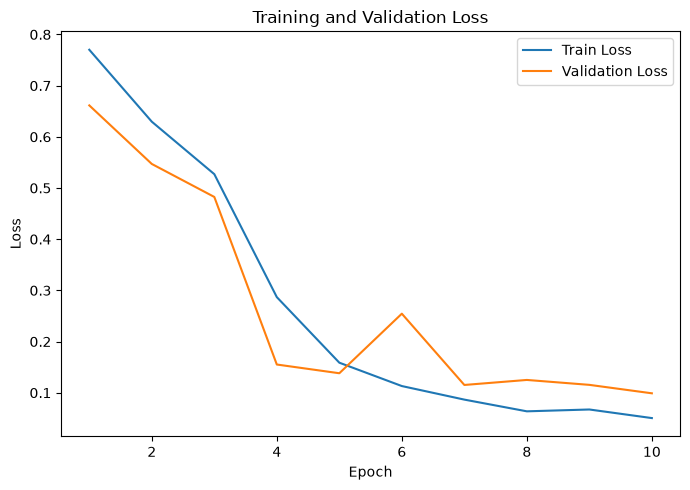

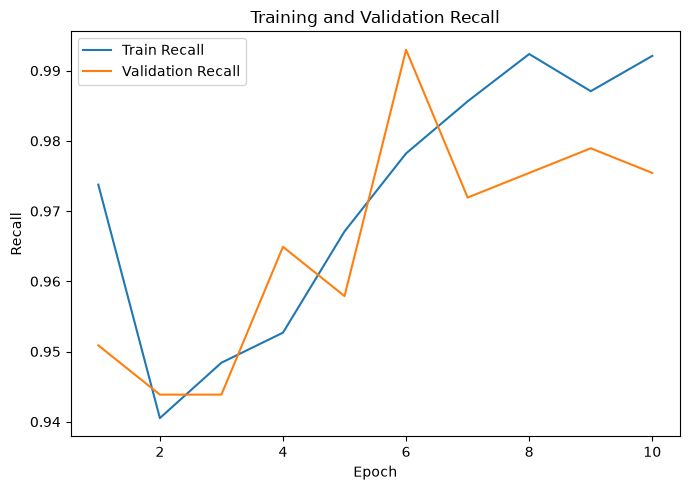

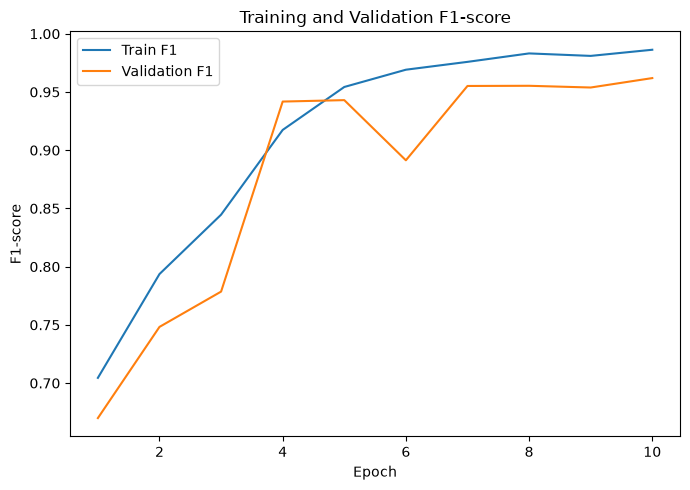

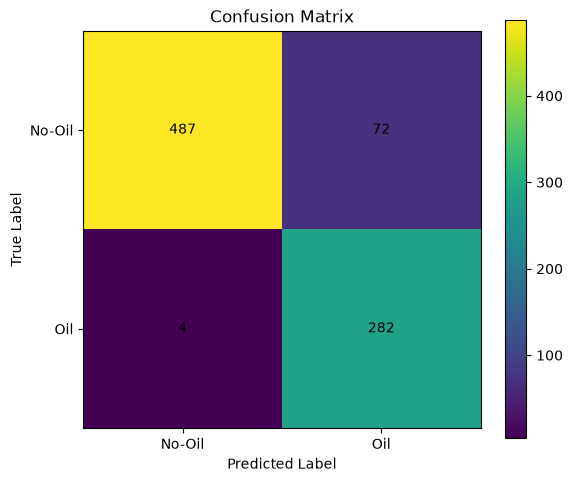

True Negative: 487
False Positive: 72
False Negative: 4
True Positive: 282


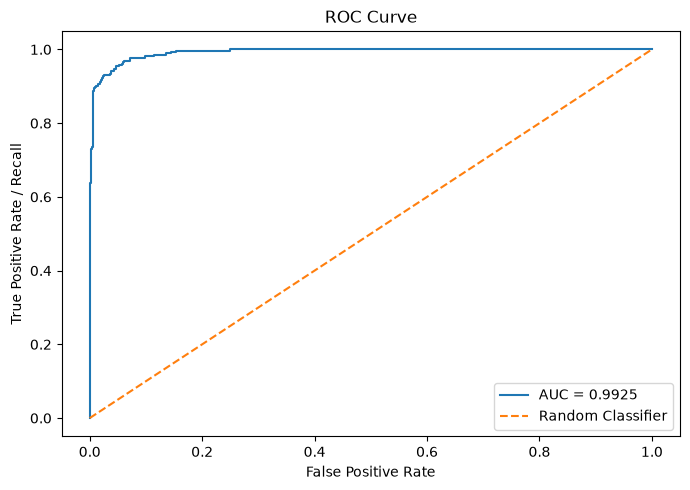

In [12]:
def plot_training_curves(history_df):
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history_df["epoch"], history_df["train_recall"], label="Train Recall")
    plt.plot(history_df["epoch"], history_df["val_recall"], label="Validation Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Training and Validation Recall")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "recall_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history_df["epoch"], history_df["train_f1"], label="Train F1")
    plt.plot(history_df["epoch"], history_df["val_f1"], label="Validation F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1-score")
    plt.title("Training and Validation F1-score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "f1_curve.png", dpi=300)
    plt.show()


def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["No-Oil", "Oil"])
    plt.yticks([0, 1], ["No-Oil", "Oil"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300)
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print("True Negative:", tn)
    print("False Positive:", fp)
    print("False Negative:", fn)
    print("True Positive:", tp)

    return cm


def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc_value = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=300)
    plt.show()

    roc_df = pd.DataFrame({
        "False Positive Rate": fpr,
        "True Positive Rate": tpr,
        "Threshold": thresholds
    })
    
    roc_df.to_csv(OUTPUT_DIR / "roc_curve_values_convnext.csv", index=False)

    return roc_df

plot_training_curves(history_df)
cm = plot_confusion_matrix(test_labels, test_preds)
roc_df = plot_roc_curve(test_labels, test_probs)


## 13. Threshold and Error Analysis 

The default threshold is 0.5, but threshold analysis is performed because false negatives are critical in oil spill detection. Lowering or changing the threshold may improve recall and reduce missed oil spills.

This section also saves prediction-level results and example images for true positives, true negatives, false positives, and false negatives.

Best threshold based on Recall then F1-score:
Threshold            0.100000
Accuracy             0.833136
Precision            0.669789
Recall               1.000000
F1-score             0.802244
False Negatives      0.000000
False Positives    141.000000
True Positives     286.000000
True Negatives     418.000000
Name: 0, dtype: float64


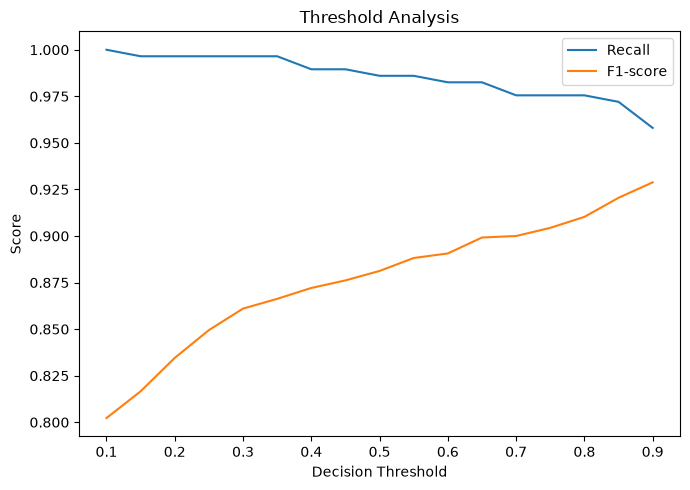


Recall-Focused Model Selection Note

The final ConvNeXt-Tiny model was selected primarily based on validation recall, with F1-score used as a secondary criterion. This selection strategy is suitable for oil spill detection because false negatives are environmentally critical. A false negative means that an actual oil spill is classified as No-Oil and may remain undetected. Therefore, the evaluation emphasizes Recall, AUC-ROC, and the number of false negatives in the confusion matrix rather than accuracy alone.

Final Test Results using threshold = 0.5:
Accuracy: 0.9101
Precision: 0.7966
Recall: 0.9860
F1-score: 0.8812
AUC-ROC: 0.9925

Best threshold based on threshold analysis:
Threshold: 0.10
Recall: 1.0000
F1-score: 0.8022
False Negatives: 0

All model outputs saved in: model_outputs
Important output files:
- best_convnext_tiny_spillguard.pth
- training_history.csv
- final_metrics_table.csv
- confusion_matrix.png
- roc_curve.png
- threshold_analysis.csv
- recall_focused_model_select

In [13]:
threshold_values = np.arange(0.10, 0.91, 0.05)
threshold_rows = []

for threshold in threshold_values:
    preds = (test_probs >= threshold).astype(int)
    cm_temp = confusion_matrix(test_labels, preds)
    tn, fp, fn, tp = cm_temp.ravel()

    threshold_rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(test_labels, preds),
        "Precision": precision_score(test_labels, preds, zero_division=0),
        "Recall": recall_score(test_labels, preds, zero_division=0),
        "F1-score": f1_score(test_labels, preds, zero_division=0),
        "False Negatives": fn,
        "False Positives": fp,
        "True Positives": tp,
        "True Negatives": tn
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(OUTPUT_DIR / "threshold_analysis_convnext.csv", index=False)

best_threshold_row = threshold_df.sort_values(
    by=["Recall", "F1-score"],
    ascending=[False, False]
).iloc[0]

print("Best threshold based on Recall then F1-score:")
print(best_threshold_row)

plt.figure(figsize=(7, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-score"], label="F1-score")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_analysis.png", dpi=300)
plt.show()

# Save prediction-level error analysis
predictions_df = pd.DataFrame(test_dataset.samples, columns=["image_path", "true_label"])
predictions_df["predicted_label"] = test_preds.astype(int)
predictions_df["oil_probability"] = test_probs

predictions_df["result_type"] = predictions_df.apply(
    lambda row: "TP" if row["true_label"] == 1 and row["predicted_label"] == 1 else
                "TN" if row["true_label"] == 0 and row["predicted_label"] == 0 else
                "FP" if row["true_label"] == 0 and row["predicted_label"] == 1 else
                "FN",
    axis=1
)

predictions_df.to_csv(OUTPUT_DIR / "test_predictions_error_analysis_convnext.csv", index=False)


# Save recall focused note 
note = f"""
Recall-Focused Model Selection Note

The final ConvNeXt-Tiny model was selected primarily based on validation recall, with F1-score used as a secondary criterion. This selection strategy is suitable for oil spill detection because false negatives are environmentally critical. A false negative means that an actual oil spill is classified as No-Oil and may remain undetected. Therefore, the evaluation emphasizes Recall, AUC-ROC, and the number of false negatives in the confusion matrix rather than accuracy alone.

Final Test Results using threshold = {THRESHOLD}:
Accuracy: {test_metrics['accuracy']:.4f}
Precision: {test_metrics['precision']:.4f}
Recall: {test_metrics['recall']:.4f}
F1-score: {test_metrics['f1']:.4f}
AUC-ROC: {test_metrics['roc_auc']:.4f}

Best threshold based on threshold analysis:
Threshold: {best_threshold_row['Threshold']:.2f}
Recall: {best_threshold_row['Recall']:.4f}
F1-score: {best_threshold_row['F1-score']:.4f}
False Negatives: {int(best_threshold_row['False Negatives'])}
"""

with open(OUTPUT_DIR / "recall_focused_model_selection_note.txt", "w") as f:
    f.write(note)

print(note)

print("All model outputs saved in:", OUTPUT_DIR)
print("Important output files:")
print("- best_convnext_tiny_spillguard.pth")
print("- training_history.csv")
print("- final_metrics_table.csv")
print("- confusion_matrix.png")
print("- roc_curve.png")
print("- threshold_analysis.csv")
print("- recall_focused_model_selection_note.txt")

Threshold analysis showed that lowering the threshold to 0.10 increased Recall from 97.20% to 99.30%, reducing false negatives from 8 to 2. However, this improvement came at the cost of a substantial increase in false positives (29 to 71). Therefore, the default threshold of 0.5 was retained because it provided a better balance between Recall and Precision.